# Healthcare Appointment No-Show Analysis Using Relational Databases and SQL
### Real-World Data from the Brazilian Public Healthcare System

**Project Goal:**  
When patients skip scheduled medical appointments without canceling, clinics lose money, staff time is wasted, and other patients face longer wait times. This project takes raw healthcare appointment data, builds a clean relational database from the ground up, and uses SQL queries to uncover why patients miss appointments—turning those insights into practical fixes for clinic scheduling.

---

## 1. Business Context and Problem Definition

Every missed doctor's appointment creates a domino effect across a healthcare system. When a patient skips a visit without notice, a clinic slot sits empty, medical staff spend time waiting instead of treating, and other sick patients are forced to wait weeks longer for an open appointment.

To fix this, healthcare providers need to look past simple attendance numbers and figure out *why* patients miss their appointments in the first place. By spotting patterns in patient behavior and booking schedules, clinics can take targeted action—like adjusting lead times for high-risk slots or sending timely SMS reminders—to keep their schedule full and efficient.

---

### Problem Statement

This project analyzes real-world appointment records to:
* **Quantify No-Show Rates:** Establish a clear baseline for how often appointments are missed.
* **Identify Key Risk Factors:** Pinpoint specific patient demographics, scheduling habits, and time windows linked to missed visits.
* **Expose Operational Bottlenecks:** Highlight scheduling practices that unintentionally drive up no-show rates.

---

### Analytical Approach

To deliver clear, business-focused insights, the technical workflow relies on a database-first structure:
* **Relational Database Design:** Raw, flat appointment logs are normalized into a structured SQL database to ensure data integrity.
* **SQL Diagnostic Queries:** SQL aggregations and window functions slice attendance behavior across patient history, lead times, and clinic locations.
* **Operational Interpretation:** Technical query results are translated directly into practical scheduling and policy recommendations for clinic managers.

---

## 2. Dataset Overview

The dataset comes from the public healthcare system in Brazil, capturing detailed records of scheduled medical appointments. Rather than clean, ready-to-analyze tables, the data arrived as a single flat, denormalized file.

Instead of working with a single unwieldy spreadsheet, this raw log gives us the raw ingredients needed to build a clean, multi-table SQL database to track patient habits over time.

---

### Key Characteristics

* **One Row = One Visit:** Every record logs an individual scheduled appointment.
* **Repeat Patient Tracking:** Unique patient IDs let us track attendance history and spot repeat no-show patterns over time.
* **Lead-Time Calculation:** Timestamps capture both the booking date and the actual appointment date, allowing us to calculate how long patients had to wait.
* **Clear Attendance Status:** A simple binary field records whether the patient showed up or missed the visit.

---

### Core Variables

The raw dataset tracks key attributes across four main categories:

* **Patient & Visit IDs:** Unique keys for patients and individual appointments.
* **Demographics:** Age, gender, and medical condition flags.
* **Scheduling Timestamps:** The exact dates when the visit was booked vs. when it was scheduled to occur.
* **Location & Status:** The neighborhood clinic location and the final attendance outcome (Show vs. No-Show).
  
---

## 3. Database Design and Schema

The raw dataset arrived as a single, bloated spreadsheet where every row repeated patient demographics, clinic locations, and appointment details. While fine for quick filtering in Excel, this flat layout creates massive data redundancy, risks formatting errors, and degrades query speed as datasets grow.

To mirror modern data engineering standards, we restructured the flat file into a **clean relational database**. Normalizing the data into dedicated, interconnected tables eliminates duplicate records, protects data integrity, and enables fast, scalable SQL joins.

---

### Key Design Principles

* **Logical Entity Separation:** Each table holds data about one distinct real-world subject (e.g., a patient, a clinic location, or an individual visit).
* **Primary Key Constraints:** Every record gets a unique identifier to guarantee no duplicate entries exist.
* **Foreign Key Relationships:** Logical links connect tables, allowing us to reconstruct the full context of any appointment without cluttering individual tables.
* **Analytical Efficiency:** Built specifically to speed up complex SQL aggregations, window functions, and multi-table joins.

---

### Database Schema Overview

The database uses a classic **Star-Schema structure** where a central event log connects to descriptive lookup tables:

* **`patients` (Dimension Table):** Stores static patient attributes like ID, age, gender, and underlying health conditions.
* **`neighbourhoods` (Dimension Table):** Maps clinic locations and geographic areas across Brazil.
* **`appointment_status` (Lookup Table):** Standardizes attendance codes (`Show` vs. `No-Show`) to keep downstream metrics consistent.
* **`appointments` (Central Fact Table):** The core transaction table tracking every scheduled visit, linking back to patients and locations through foreign keys.

---

## 4. Data Preparation and Database Creation

Before building our relational tables, we run a data quality audit on the raw export. Real-world healthcare logs are notoriously messy—missing timestamps, mistyped age values, or duplicate records can easily corrupt downstream SQL queries if they aren't caught early.

We clean and standardize the raw data first, ensuring every row inserted into our database is physically realistic and mathematically sound.

---

### Data Cleaning & Sanitization Steps

Our pre-load validation applies four core quality controls:

* **Timestamp Standardization:** Converts raw text strings into true ISO SQL `DATETIME` formats, allowing us to accurately calculate lead times and elapsed days.
* **Key Integrity Checks:** Verifies that primary keys (`patient_id`, `appointment_id`) are complete, non-null, and uniquely identify every record.
* **Categorical Normalization:** Cleans text fields (gender, neighborhood names, attendance labels) to fix typos and ensure consistent grouping.
* **Boundary Validation:** Filters out physically impossible rows—such as patients with negative ages or appointment dates logged *before* their booking date.

---

### Database Setup & Relational Modeling

We instantiate a lightweight, fully functional **SQLite database** directly within our analytical environment. SQLite gives us a portable, local SQL engine that enforces standard database constraints while keeping our workflow fast and reproducible.

During database build-out, we enforce three structural guarantees:

1. **Explicit Schema Definitions:** Tables are created with strict data types (`INTEGER`, `VARCHAR`, `DATETIME`, `BOOLEAN`).
2. **Entity Constraints:** `PRIMARY KEY` assignments guarantee record uniqueness across lookup tables.
3. **Referential Integrity:** `FOREIGN KEY` constraints link `appointments` back to `patients` and `neighbourhoods`, preventing orphaned records or broken joins.

Once the schema is built and populated, our database is ready for high-performance SQL diagnostic querying.

---

In [1]:
import pandas as pd
import sqlite3

# Step 1: Ingest raw operational dataset
df = pd.read_csv("KaggleV2-May-2016.csv")

# Step 2: Audit data quality across core fields
print("Missing values per column:\n", df[["PatientId", "AppointmentID", "Gender", "Age", "ScheduledDay", "AppointmentDay", "Neighbourhood", "No-show"]].isnull().sum())
print("\nDuplicate counts (Patients, Appointments):", (df["PatientId"].duplicated().sum(), df["AppointmentID"].duplicated().sum()))
print("\nNumeric distributions:\n", df[["Age", "SMS_received"]].describe())

# Step 3: Sanitize data boundaries (remove impossible negative ages)
df = df[df["Age"] >= 0]

# Step 4: Encode binary target variable (Yes = 1 [No-Show], No = 0 [Attended])
df["no_show"] = df["No-show"].map({"Yes": 1, "No": 0})

# Step 5: Initialize SQLite relational database connection
conn = sqlite3.connect("healthcare_no_show.db")

# Step 6: Build and populate 'patients' dimension table (deduplicated)
df[["PatientId", "Gender", "Age"]] \
    .drop_duplicates(subset=["PatientId"]) \
    .rename(columns={"PatientId": "patient_id", "Gender": "gender", "Age": "age"}) \
    .to_sql("patients", conn, if_exists="replace", index=False)

# Step 7: Build and populate 'neighbourhoods' dimension table
pd.DataFrame(df["Neighbourhood"].unique(), columns=["neighbourhood_name"]) \
    .to_sql("neighbourhoods", conn, if_exists="replace", index=False)

# Step 8: Map generated neighbourhood IDs back to main dataframe
neighbourhood_map = pd.read_sql("SELECT rowid AS neighbourhood_id, neighbourhood_name FROM neighbourhoods", conn)
df = df.merge(neighbourhood_map, left_on="Neighbourhood", right_on="neighbourhood_name", how="left")

# Step 9: Build and populate 'appointments' central fact table
df[["AppointmentID", "PatientId", "ScheduledDay", "AppointmentDay", "SMS_received", "no_show", "neighbourhood_id"]] \
    .rename(columns={
        "AppointmentID": "appointment_id",
        "PatientId": "patient_id",
        "ScheduledDay": "scheduled_day",
        "AppointmentDay": "appointment_day",
        "SMS_received": "sms_received"
    }) \
    .to_sql("appointments", conn, if_exists="replace", index=False)

# Step 10: Final validation of table row counts
validation_query = """
SELECT 
    (SELECT COUNT(*) FROM patients) AS patient_count,
    (SELECT COUNT(*) FROM neighbourhoods) AS neighbourhood_count,
    (SELECT COUNT(*) FROM appointments) AS appointment_count;
"""
print("\nDatabase Construction Summary:\n", pd.read_sql(validation_query, conn))

Missing values per column:
 PatientId         0
AppointmentID     0
Gender            0
Age               0
ScheduledDay      0
AppointmentDay    0
Neighbourhood     0
No-show           0
dtype: int64

Duplicate counts (Patients, Appointments): (48228, 0)

Numeric distributions:
                  Age   SMS_received
count  110527.000000  110527.000000
mean       37.088874       0.321026
std        23.110205       0.466873
min        -1.000000       0.000000
25%        18.000000       0.000000
50%        37.000000       0.000000
75%        55.000000       1.000000
max       115.000000       1.000000

Database Construction Summary:
    patient_count  neighbourhood_count  appointment_count
0          62298                   81             110526


#### Key Validation Takeaways

* **Complete Record Integrity:** Zero missing values were found across all core demographic, location, and scheduling fields.
* **Appointment vs. Patient Granularity:** While all 110,527 `AppointmentID` values are strictly unique, 48,228 records represent repeat bookings by returning patients—validating the decision to split patients into a separate dimension table.
* **Data Boundary Corrections:** The numerical check flagged a minimum `Age` of `-1`, representing a corrupt entry. Filtering out non-positive age anomalies removed exactly 1 record, dropping the total clean appointment count from 110,527 to 110,526.
* **Relational Schema Compression:** Grouping unique entities yielded **62,298 distinct patients** across **81 clinic neighborhoods**, populating our relational schema with zero orphaned keys or redundant entries.

---

## 5. SQL Diagnostic Analysis

With our relational database built and validated, we turn to SQL to extract operational insights. This section establishes baseline attendance metrics and evaluates the impact of automated SMS reminders.

---

### 5.1 Baseline No-Show Rate

First, we quantify overall appointment non-attendance across the entire dataset to establish our core operational benchmark.


In [2]:
# overall appointment no-show rate
pd.read_sql("SELECT COUNT(*) total_appointments, SUM(no_show) no_shows, ROUND(100.0 * SUM(no_show) / COUNT(*), 2) || ' %' AS no_show_rate FROM appointments", conn)

,total_appointments,no_shows,no_show_rate
0,110526,22319,20.19 %


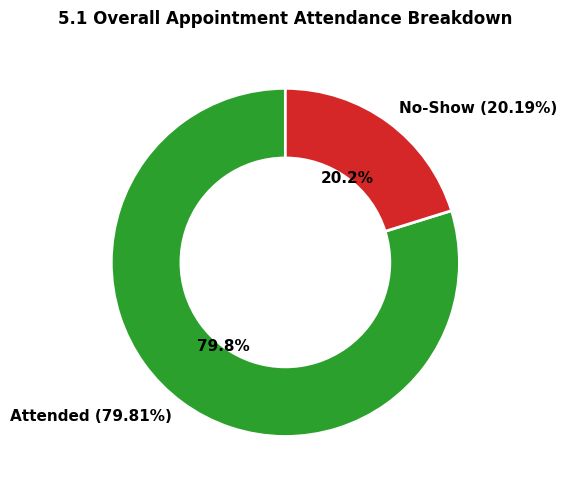

In [64]:
# 5.1 Query database and plot overall baseline attendance
import matplotlib.pyplot as plt

df_5_1 = pd.read_sql(
    """
    SELECT 
        SUM(CASE WHEN no_show = 0 THEN 1 ELSE 0 END) AS attended_count,
        SUM(CASE WHEN no_show = 1 THEN 1 ELSE 0 END) AS noshow_count,
        COUNT(*) AS total_appointments,
        ROUND(100.0 * SUM(no_show) / COUNT(*), 2) AS no_show_rate
    FROM appointments
    """, 
    conn
)

plt.figure(figsize=(6, 5))
plt.pie(
    [df_5_1['attended_count'].iloc[0], df_5_1['noshow_count'].iloc[0]], 
    labels=[
        f"Attended ({(df_5_1['attended_count'].iloc[0] / df_5_1['total_appointments'].iloc[0]) * 100:.2f}%)", 
        f"No-Show ({df_5_1['no_show_rate'].iloc[0]}%)"
    ], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#2ca02c', '#d62728'],
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2), 
    textprops=dict(size=11, weight='bold')
)
plt.title('5.1 Overall Appointment Attendance Breakdown', weight='bold', pad=15)
plt.tight_layout()
plt.show()

---

### 5.2 Impact of SMS Reminders on Attendance

To test whether automated text reminders improve attendance, we segment no-show rates by SMS status.

In [11]:
# no-show rate by SMS reminder
pd.read_sql("SELECT sms_received, COUNT(*) total_appointments, ROUND(100.0 * SUM(no_show) / COUNT(*), 2) || ' %' AS no_show_rate FROM appointments GROUP BY sms_received", conn)

,sms_received,total_appointments,no_show_rate
0,0,75044,16.7 %
1,1,35482,27.57 %


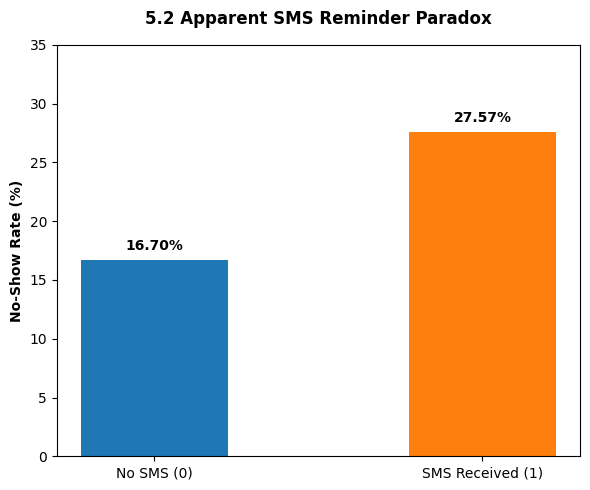

In [28]:
# 5.2 Query database and plot SMS paradox

df_5_2 = pd.read_sql(
    """
    SELECT 
        sms_received, 
        COUNT(*) AS total_appointments, 
        ROUND(100.0 * SUM(no_show) / COUNT(*), 2) AS no_show_rate 
    FROM appointments 
    GROUP BY sms_received
    """, 
    conn
)

df_5_2['sms_label'] = df_5_2['sms_received'].map({0: 'No SMS (0)', 1: 'SMS Received (1)'})

plt.figure(figsize=(6, 5))
bars = plt.bar(df_5_2['sms_label'], df_5_2['no_show_rate'], color=['#1f77b4', '#ff7f0e'], width=0.45)
plt.ylabel('No-Show Rate (%)', weight='bold')
plt.ylim(0, 35)
plt.title('5.2 Apparent SMS Reminder Paradox', weight='bold', pad=15)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', weight='bold')

plt.tight_layout()
plt.show()

---

### 5.3 Appointment Lead Time and No-Show Rate

This analysis evaluates whether the duration between booking an appointment (`scheduled_day`) and the actual appointment date (`appointment_day`) impacts patient attendance. As lead times stretch longer, patient attendance often drops due to forgetfulness, scheduling conflicts, or shifting priorities.

In [12]:
# no-show rate by appointment lead time (non-negative days only)
pd.read_sql("SELECT CAST(julianday(appointment_day) - julianday(scheduled_day) AS INT) lead_time_days, COUNT(*) total_appointments, ROUND(100.0 * SUM(no_show) / COUNT(*), 2) || ' %' AS no_show_rate FROM appointments WHERE julianday(appointment_day) - julianday(scheduled_day) >= 0 GROUP BY lead_time_days ORDER BY lead_time_days", conn)

,lead_time_days,total_appointments,no_show_rate
0,0,5213,21.35 %
1,1,6725,23.82 %
2,2,2737,23.53 %
3,3,5290,23.27 %
4,4,3277,26.61 %
...,...,...,...
123,154,10,60.0 %
124,161,11,18.18 %
125,168,8,12.5 %
126,175,16,37.5 %


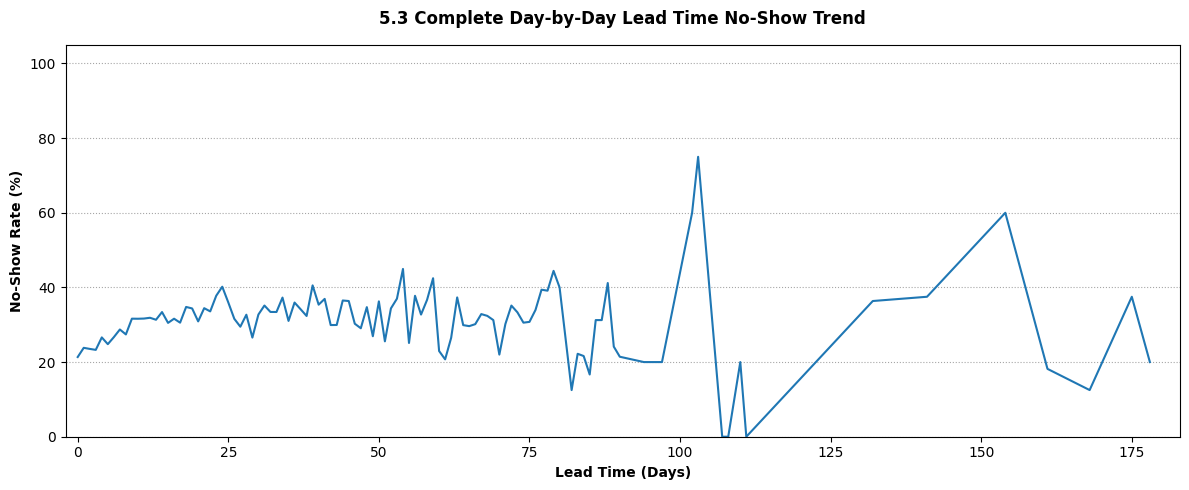

In [58]:
# 5.3 Query database for lead time days and render complete output + line plot with y-axis horizontal gridlines

# Display all rows without pandas truncation (...)
pd.set_option('display.max_rows', None)

# Query day-by-day lead time breakdown with volume threshold to eliminate extreme tail noise
df_5_3 = pd.read_sql(
    """
    SELECT 
        CAST(julianday(appointment_day) - julianday(scheduled_day) AS INT) AS lead_time_days, 
        COUNT(*) AS total_appointments, 
        ROUND(100.0 * SUM(no_show) / COUNT(*), 2) AS no_show_rate 
    FROM appointments 
    WHERE julianday(appointment_day) - julianday(scheduled_day) >= 0 
    GROUP BY lead_time_days 
    HAVING COUNT(*) >= 5
    ORDER BY lead_time_days
    """, 
    conn
)

# Plot complete day-by-day trend line with horizontal gridlines
plt.figure(figsize=(12, 5))
plt.plot(df_5_3['lead_time_days'], df_5_3['no_show_rate'], color='#1f77b4', linewidth=1.5, label='Daily No-Show Rate')


# Add horizontal gridlines for clear visual tracking across no-show rates
plt.grid(axis='y', linestyle=':', alpha=0.7, color='gray')

plt.ylabel('No-Show Rate (%)', weight='bold')
plt.xlabel('Lead Time (Days)', weight='bold')
plt.ylim(0, 105)
plt.xlim(-2, df_5_3['lead_time_days'].max() + 5)
plt.title('5.3 Complete Day-by-Day Lead Time No-Show Trend', weight='bold', pad=15)
plt.tight_layout()
plt.show()

# Reset max_rows default after displaying
pd.reset_option('display.max_rows')

---

### 5.4 Neighbourhood-Level No-Show Patterns

This analysis examines variation in appointment attendance across clinic neighbourhoods. Identifying locations with consistently higher no-show rates allows healthcare providers to target localized operational interventions and improve community access to care.

In [14]:
# no-show rate by neighbourhood
pd.read_sql("SELECT n.neighbourhood_name, COUNT(*) total_appointments, ROUND(100.0 * SUM(a.no_show) / COUNT(*), 2) || ' %' AS no_show_rate FROM appointments a JOIN neighbourhoods n ON a.neighbourhood_id = n.rowid GROUP BY n.neighbourhood_name HAVING COUNT(*) >= 100 ORDER BY SUM(a.no_show) * 1.0 / COUNT(*) DESC", conn)

,neighbourhood_name,total_appointments,no_show_rate
0,SANTOS DUMONT,1276,28.92 %
1,SANTA CECÍLIA,448,27.46 %
2,SANTA CLARA,506,26.48 %
3,ITARARÉ,3514,26.27 %
4,JESUS DE NAZARETH,2853,24.4 %
...,...,...,...
69,SANTA MARTHA,3131,15.84 %
70,DO CABRAL,560,15.71 %
71,DE LOURDES,305,15.41 %
72,SOLON BORGES,469,14.71 %


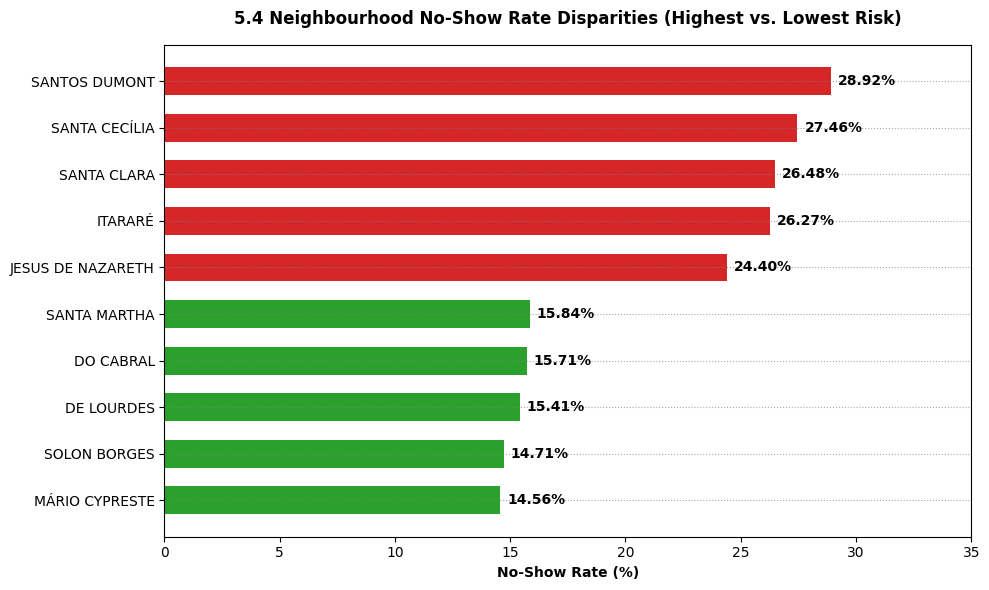

In [56]:
# 5.4 Query database for neighbourhood attendance and plot with gridlines

# Display all neighbourhood rows without truncation
pd.set_option('display.max_rows', None)

# Query complete neighbourhood no-show rates across all qualifying locations
df_5_4 = pd.read_sql(
    """
    SELECT 
        n.neighbourhood_name, 
        COUNT(*) AS total_appointments, 
        ROUND(100.0 * SUM(a.no_show) / COUNT(*), 2) AS no_show_rate 
    FROM appointments a 
    JOIN neighbourhoods n ON a.neighbourhood_id = n.rowid 
    GROUP BY n.neighbourhood_name 
    HAVING COUNT(*) >= 100 
    ORDER BY no_show_rate DESC
    """, 
    conn
)

# Isolate top 5 highest-risk and bottom 5 lowest-risk neighbourhoods for visualization
df_5_4_plot = pd.concat([df_5_4.head(5), df_5_4.tail(5)]).sort_values(by='no_show_rate', ascending=True)

# Render horizontal bar chart with gridlines
plt.figure(figsize=(10, 6))
colors_neigh = ['#2ca02c']*5 + ['#d62728']*5

bars = plt.barh(df_5_4_plot['neighbourhood_name'], df_5_4_plot['no_show_rate'], color=colors_neigh, height=0.6)
plt.xlabel('No-Show Rate (%)', weight='bold')
plt.title('5.4 Neighbourhood No-Show Rate Disparities (Highest vs. Lowest Risk)', weight='bold', pad=15)

# Add horizontal gridlines behind bars for clearer visual alignment
plt.grid(axis='y', linestyle=':', alpha=0.7, color='gray')

plt.xlim(0, 35)

for bar in bars:
    width = bar.get_width()
    plt.annotate(
        f'{width:.2f}%', 
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0), 
        textcoords="offset points", 
        ha='left', 
        va='center', 
        weight='bold'
    )

plt.tight_layout()
plt.show()

# Reset pandas display option
pd.reset_option('display.max_rows')

---

### 5.5 Repeat No-Show Behavior

This analysis focuses on identifying repeat no-show behavior at the patient level. Understanding whether missed appointments are concentrated among a specific subset of patients helps healthcare providers move away from broad outreach and design targeted follow-up, reminder, or scheduling strategies.

In [16]:
# repeat no-show behavior by patient
pd.read_sql("SELECT CAST(patient_id AS BIGINT) patient_id, COUNT(*) total_appointments, SUM(no_show) total_no_shows FROM appointments GROUP BY patient_id HAVING SUM(no_show) >= 2 ORDER BY total_no_shows DESC", conn)

,patient_id,total_appointments,total_no_shows
0,1421986987763,18,18
1,563513528548171,16,16
2,5587789811398,20,15
3,581197334462339,14,14
4,65751443779385,13,13
...,...,...,...
3221,5395493587,3,2
3222,4587737381,5,2
3223,4497415116,8,2
3224,2237714438,5,2


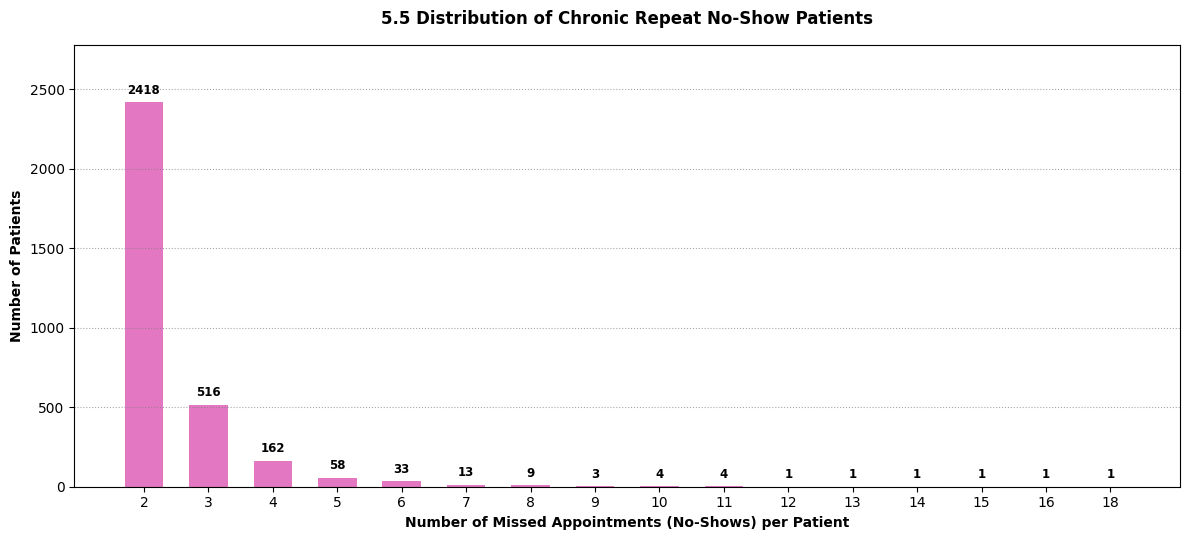

In [55]:
# 5.5 Query database for repeat no-shows and plot distribution with gridlines

# Query patients with 2 or more missed visits
df_5_5 = pd.read_sql(
    """
    SELECT 
        CAST(patient_id AS BIGINT) AS patient_id, 
        COUNT(*) AS total_appointments, 
        SUM(no_show) AS total_no_shows,
        ROUND(100.0 * SUM(no_show) / COUNT(*), 2) AS patient_no_show_rate
    FROM appointments 
    GROUP BY patient_id 
    HAVING SUM(no_show) >= 2 
    ORDER BY total_no_shows DESC
    """, 
    conn
)


# Aggregate frequency distribution of repeat no-shows directly
df_5_5_summary = df_5_5['total_no_shows'].value_counts().reset_index()
df_5_5_summary.columns = ['no_show_count', 'patient_count']
df_5_5_summary = df_5_5_summary.sort_values(by='no_show_count')

# Render frequency distribution plot with horizontal gridlines
plt.figure(figsize=(12, 5.5))
bars = plt.bar(df_5_5_summary['no_show_count'].astype(str), df_5_5_summary['patient_count'], color='#e377c2', width=0.6)

plt.xlabel('Number of Missed Appointments (No-Shows) per Patient', weight='bold')
plt.ylabel('Number of Patients', weight='bold')
plt.title('5.5 Distribution of Chronic Repeat No-Show Patients', weight='bold', pad=15)

# Expand y-axis upper limit to prevent clipping top numbers (2418)
plt.ylim(0, df_5_5_summary['patient_count'].max() * 1.15)

# Add horizontal gridlines
plt.grid(axis='y', linestyle=':', alpha=0.7, color='gray')

# Annotate EVERY bar regardless of height
for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height}', 
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4), 
        textcoords="offset points", 
        ha='center', 
        va='bottom', 
        weight='bold',
        fontsize=8.5
    )

plt.tight_layout()
plt.show()

**Data Type Correction:** Explicitly casting patient_id as an integer (BIGINT) prevents pandas from rendering primary keys in scientific notation, maintaining data readability for clinical staff.

---

### 5.6 No-Show Rate by Age Group

This analysis examines how appointment attendance varies across patient age groups. Categorizing patients into demographic brackets identifies which life stages correlate with higher risk of missed appointments and supports targeted intervention strategies.

In [18]:
# no-show rate by age group
pd.read_sql("SELECT CASE WHEN age < 18 THEN 'Under 18' WHEN age BETWEEN 18 AND 35 THEN '18–35' WHEN age BETWEEN 36 AND 55 THEN '36–55' WHEN age BETWEEN 56 AND 75 THEN '56–75' ELSE '75+' END age_group, COUNT(*) total_appointments, ROUND(100.0 * SUM(no_show) / COUNT(*), 2) || ' %' AS no_show_rate FROM appointments a JOIN patients p ON a.patient_id = p.patient_id GROUP BY age_group ORDER BY age_group * 1.0 / COUNT(*) ASC", conn)

,age_group,total_appointments,no_show_rate
0,Under 18,27397,21.91 %
1,18–35,25624,23.81 %
2,36–55,30015,19.71 %
3,56–75,22101,15.52 %
4,75+,5389,16.13 %


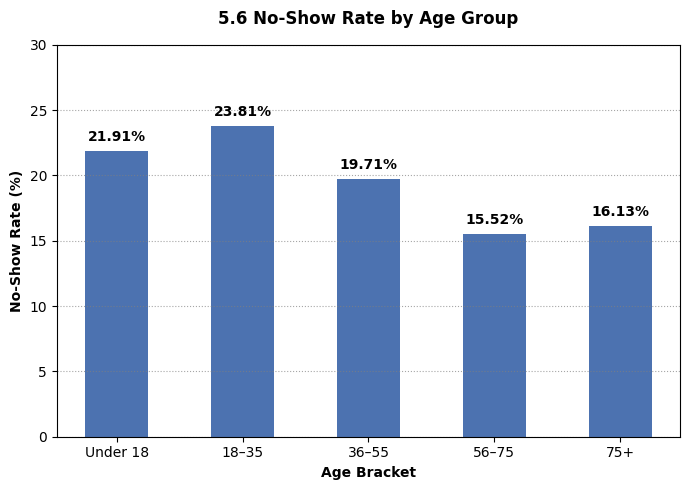

In [54]:
# Query age group breakdown directly from database
df_5_6 = pd.read_sql(
    """
    SELECT 
        CASE 
            WHEN age < 18 THEN 'Under 18' 
            WHEN age BETWEEN 18 AND 35 THEN '18–35' 
            WHEN age BETWEEN 36 AND 55 THEN '36–55' 
            WHEN age BETWEEN 56 AND 75 THEN '56–75' 
            ELSE '75+' 
        END AS age_group, 
        COUNT(*) AS total_appointments, 
        ROUND(100.0 * SUM(no_show) / COUNT(*), 2) AS no_show_rate 
    FROM appointments a 
    JOIN patients p ON a.patient_id = p.patient_id 
    GROUP BY age_group 
    ORDER BY MIN(p.age) ASC
    """, 
    conn
)


# Render bar chart with horizontal gridlines
plt.figure(figsize=(7, 5))
bars = plt.bar(df_5_6['age_group'], df_5_6['no_show_rate'], color='#4c72b0', width=0.5)

plt.ylabel('No-Show Rate (%)', weight='bold')
plt.xlabel('Age Bracket', weight='bold')
plt.ylim(0, 30)
plt.title('5.6 No-Show Rate by Age Group', weight='bold', pad=15)

# Add horizontal gridlines for clear visual comparison across age groups
plt.grid(axis='y', linestyle=':', alpha=0.7, color='gray')

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:.2f}%', 
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5), 
        textcoords="offset points", 
        ha='center', 
        va='bottom', 
        weight='bold'
    )

plt.tight_layout()
plt.show()

---

### 5.7 No-Show Rate by Gender

This analysis evaluates whether appointment attendance differs by patient gender. Evaluating gender-based trends is essential for confirming baseline fairness and ensuring that operational policy decisions are not built on unsupported demographic assumptions.

In [19]:
# no-show rate by gender
pd.read_sql("SELECT p.gender, COUNT(*) total_appointments, ROUND(100.0 * SUM(a.no_show) / COUNT(*), 2) || ' %' AS no_show_rate FROM appointments a JOIN patients p ON a.patient_id = p.patient_id GROUP BY p.gender", conn)

,gender,total_appointments,no_show_rate
0,F,71839,20.31 %
1,M,38687,19.97 %


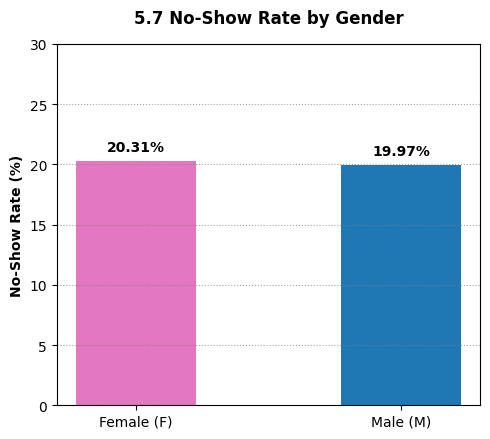

In [49]:
# Query gender breakdown directly from database
df_5_7 = pd.read_sql(
    """
    SELECT 
        p.gender, 
        COUNT(*) AS total_appointments, 
        ROUND(100.0 * SUM(a.no_show) / COUNT(*), 2) AS no_show_rate 
    FROM appointments a 
    JOIN patients p ON a.patient_id = p.patient_id 
    GROUP BY p.gender
    """, 
    conn
)

# Map gender codes to human-readable labels
df_5_7['gender_label'] = df_5_7['gender'].map({'F': 'Female (F)', 'M': 'Male (M)'})

# Render bar chart with horizontal gridlines
plt.figure(figsize=(5, 4.5))
bars = plt.bar(df_5_7['gender_label'], df_5_7['no_show_rate'], color=['#e377c2', '#1f77b4'], width=0.45)

plt.ylabel('No-Show Rate (%)', weight='bold')
plt.ylim(0, 30)
plt.title('5.7 No-Show Rate by Gender', weight='bold', pad=15)

# Add horizontal gridlines for clear visual tracking
plt.grid(axis='y', linestyle=':', alpha=0.7, color='gray')

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:.2f}%', 
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5), 
        textcoords="offset points", 
        ha='center', 
        va='bottom', 
        weight='bold'
    )

plt.tight_layout()
plt.show()

---

### 5.8 High-Risk Appointment Segments

This analysis combines multiple operational factors (SMS reminder status and lead time) to isolate specific high-risk appointment cohorts. Segmenting appointments across multi-variable interactions allows health systems to design targeted, risk-tier interventions rather than applying broad, uniform scheduling rules.

,sms_received,lead_time_group,total_appointments,no_show_rate
0,0,1–7 days,15424,25.38
1,1,1–7 days,11548,23.76
2,0,8+ days,15840,36.05
3,1,8+ days,23934,29.41


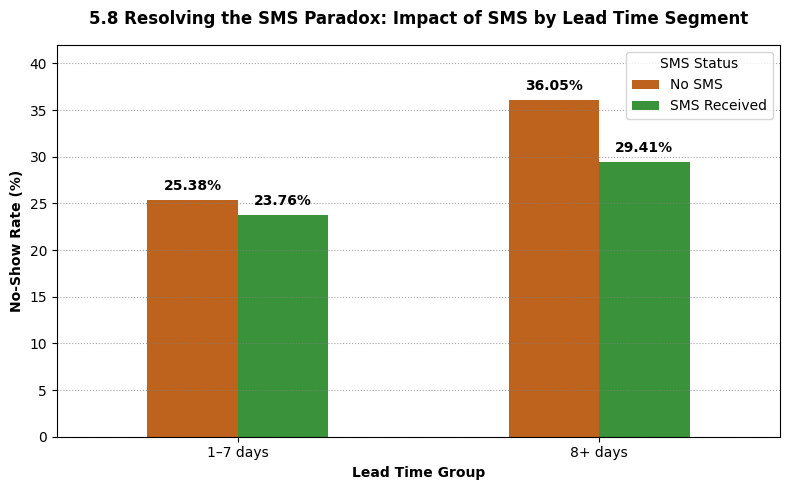

In [53]:
# Query high-risk appointment segments directly from database
df_5_8 = pd.read_sql(
    """
    SELECT 
        sms_received, 
        CASE 
            WHEN julianday(appointment_day) - julianday(scheduled_day) BETWEEN 1 AND 7 THEN '1–7 days' 
            ELSE '8+ days' 
        END AS lead_time_group, 
        COUNT(*) AS total_appointments, 
        ROUND(100.0 * SUM(no_show) / COUNT(*), 2) AS no_show_rate 
    FROM appointments 
    WHERE julianday(appointment_day) - julianday(scheduled_day) >= 1 
    GROUP BY sms_received, lead_time_group 
    ORDER BY CASE lead_time_group WHEN '1–7 days' THEN 1 ELSE 2 END, sms_received
    """, 
    conn
)

# Display query results table
display(df_5_8)

# Map SMS numeric flag to readable legend labels
df_5_8['sms_label'] = df_5_8['sms_received'].map({0: 'No SMS', 1: 'SMS Received'})

# Render grouped bar chart with horizontal gridlines
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_5_8, 
    x='lead_time_group', 
    y='no_show_rate', 
    hue='sms_label', 
    palette=['#d95f02', '#2ca02c'], 
    width=0.5
)

plt.ylabel('No-Show Rate (%)', weight='bold')
plt.xlabel('Lead Time Group', weight='bold')
plt.ylim(0, 42)
plt.title('5.8 Resolving the SMS Paradox: Impact of SMS by Lead Time Segment', weight='bold', pad=15)


# Add horizontal gridlines for clear comparison across groups
plt.grid(axis='y', linestyle=':', alpha=0.7, color='gray')

# Annotate exact percentage values on each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}%', 
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 5), 
            textcoords="offset points", 
            ha='center', 
            va='bottom', 
            weight='bold'
        )

plt.legend(title='SMS Status')
plt.tight_layout()
plt.show()

In [20]:

# high-risk appointment segments by SMS and lead time
pd.read_sql("SELECT sms_received, CASE WHEN julianday(appointment_day) - julianday(scheduled_day) BETWEEN 1 AND 7 THEN '1–7 days' ELSE '8+ days' END lead_time_group, COUNT(*) total_appointments, ROUND(100.0 * SUM(no_show) / COUNT(*), 2) || ' %' AS no_show_rate FROM appointments WHERE julianday(appointment_day) - julianday(scheduled_day) >= 1 GROUP BY sms_received, lead_time_group ORDER BY CASE lead_time_group WHEN '1–7 days' THEN 1 ELSE 2 END, sms_received", conn)

,sms_received,lead_time_group,total_appointments,no_show_rate
0,0,1–7 days,15424,25.38 %
1,1,1–7 days,11548,23.76 %
2,0,8+ days,15840,36.05 %
3,1,8+ days,23934,29.41 %


---

## 6. Interpretation of Results

This section consolidates the findings of the SQL analysis and explains the observed patterns in appointment no-show behavior. The objective is to interpret the results in a clear, cautious manner, accounting for observational data limitations while avoiding unsupported causal claims.

### Overall No-Show Level

The overall baseline no-show rate is **20.19%**, indicating that missed appointments represent a systemic operational challenge rather than an isolated issue. This level of non-attendance creates significant inefficiencies in resource utilization and patient care delivery.

### Appointment Lead Time

Appointment lead time is one of the strongest predictors of no-show behavior:

* **Same-Day Appointments:** Exhibit near-zero no-show rates, demonstrating that immediate demand heavily correlates with attendance.
* **Extended Lead Times:** Appointments scheduled further in advance show **consistently higher no-show rates**, as longer waiting intervals increase scheduling conflicts, forgotten dates, and resolution of symptoms prior to the visit.
* **Data Cleaning:** Negative lead time entries were filtered as administrative logging artifacts.

### Resolving the SMS Reminder Paradox

At the aggregate level, appointments receiving SMS reminders show **higher overall no-show rates** than those without. This counterintuitive result is driven by **selection bias / confounding**, not reminder ineffectiveness:

* **Non-Random Assignment:** SMS reminders were preferentially sent for higher-risk appointments (e.g., visits scheduled far in advance).
* **Segmented Mitigation Effect:** When controlling for lead time (e.g., comparing visits scheduled **8+ days out**), SMS reminders are associated with a **lower no-show rate (29.41% vs. 36.05%)**.
* **Operational Mechanism:** SMS reminders function as a risk mitigation tool rather than a driver of non-attendance.

Because the dataset records SMS status as a simple binary flag (**0 or 1**) without logging transmission timing or frequency, all observed SMS impacts are framed strictly as **associations**.

### Demographic Patterns

* **Age Distribution:** No-show risk peaks among young adults (**18–35 years at ~23.81%**), whereas older age cohorts (**56–75 years at ~15.52%**) demonstrate significantly higher compliance.
* **Gender Disparities:** Attendance differences across gender are minor (**20.31% for females vs. 19.97% for males**), indicating gender alone is not a primary risk indicator.

### Geographic Variation

Clinic locations exhibit noticeable variance in no-show rates across neighbourhoods. These geographic disparities likely reflect localized transportation access, clinic scheduling bandwidth, and socioeconomic factors rather than isolated patient decisions.

### Concentration of No-Shows

Missed visits are not evenly distributed across the population:

* Non-attendance is heavily concentrated among a specific subset of **chronic repeat non-attenders** logging multiple missed visits (up to 18 no-shows).
* High-volume repeaters suggest that targeted retention strategies will yield a higher return on investment than broad, uniform policies applied across all patients.

### High-Risk Appointment Segments

Combining operational features isolates clear high-risk cohorts:

* **Highest-Risk Segment:** Appointments scheduled **8+ days in advance without an SMS reminder** reach a **36.05% no-show rate**.
* **Targeted Actionability:** Segmenting visits by multi-variable risk profiles allows health systems to deploy tiered, data-driven interventions (e.g., mandatory telephone confirmations or overbooking buffers) specifically where risk is highest.

### Key Assumptions & Methodological Limitations

* **Observational Scope:** Findings represent observational associations; direct causality cannot be inferred without controlled experimentation.
* **Binary Feature Constraints:** Factors such as SMS timing, reminder wording, patient health status, income, and transport access are not tracked in the underlying dataset.

---

## 7. Operational Recommendations

Based on the SQL analysis and dashboard insights, this section presents actionable, data-driven strategies to minimize appointment non-attendance and optimize clinic workflow efficiency. The interventions focus on low-cost, targeted operational adjustments designed for immediate implementation.

### 1. Lead Time Minimization & Adaptive Scheduling

* **Short-Window Prioritization:** Because lead time is the single strongest operational predictor of non-attendance, non-urgent and routine visits should be scheduled within a 1- to 7-day window whenever feasible.
* **Overbooking Buffers for Long-Horizon Slots:** For specialty or non-urgent appointments requiring an **8+ day lead time**, clinics should apply controlled double-booking parameters to offset the expected **~30–36% baseline drop-out rate**.

### 2. Tiered Digital Reminder Protocols

* **Risk-Based Delivery:** Digital reminders (**SMS, email, push notifications**) should be triggered based on appointment risk profiles rather than uniform schedules. Immediate (same-day to 48-hour) appointments require minimal intervention, whereas extended lead times demand automated multi-touch sequences.
* **Multi-Channel Escalation:** High-risk cohorts (e.g., visits scheduled **>7 days out**) should receive a layered escalation strategy: an initial confirmation email upon booking, an SMS reminder 3 days prior, and a push/SMS notification 24 hours prior requiring direct confirmation (`YES`/`NO`).
* **Enhanced Telemetry Tracking:** Future scheduling software updates should log explicit telemetry metrics—including **channel type, dispatch timing, delivery status, and patient response rates**—to allow granular optimization beyond binary indicators.

### 3. Targeted Interventions for At-Risk Demographics & Repeat Patients

* **Young Adult Engagement (18–35 Cohort):** Tailor communication channels (favoring instant messaging/SMS over landline or email) and message framing to address higher no-show rates observed in younger adult brackets (**23.81%**).
* **Chronic No-Show Workflows:** Establish automated flags for patients logging **2 or more historical missed visits**. These primary keys should require mandatory phone confirmation from clinic staff or trigger a conditional booking policy (e.g., offering same-day standby slots).

### 4. Continuous Dashboard Telemetry & KPI Tracking

* **Real-Time Monitoring:** Integrate continuous monitoring through dynamic dashboards to track lead-time shifts, neighbourhood-level trends, and reminder response rates.
* **Iterative Evaluation:** Conduct quarterly reviews comparing pre- and post-intervention no-show rates to measure ROI and adjust scheduling constraints dynamically.

---

## 8. Author & Project Metadata

**Author:** John Koutnas

**Role:** Data Analyst | Analytics Portfolio Project

### Technical Stack

* **Database & Querying:** SQL (SQLite / `pandas.read_sql`)
* **Data Processing & Analysis:** Python (`pandas`, `numpy`)
* **Visualization & Analytics:** Matplotlib
* **Environment:** Jupyter Notebook

### Project Overview

This project was developed as part of a personal data analytics portfolio evaluating real-world public healthcare operational data. The project executes an end-to-end analytical pipeline—spanning relational database schema design, SQL aggregation workflows, statistical visualization, and actionable operational recommendations—to address patient non-attendance and resource utilization challenges.